In [1]:
suppressPackageStartupMessages({
    library(NanoStringNCTools)
    library(fpc)
    library(plotly)
    library(knitr)
    library(GeomxTools)
    library(GeoMxWorkflows)
    library(ggplot2)
    library(scales)
    library(dplyr)
    library(ggforce)
    library(reshape2)
    library(readxl)
})
cd45_color = '#F8766D'
ck_color = '#00BA38'
cd68_color = '#619CFF'
options(repr.plot.width=NULL, repr.plot.height=NULL)


Warning message:
“package ‘NanoStringNCTools’ was built under R version 4.4.2”
Warning message:
“package ‘Biobase’ was built under R version 4.4.2”
Warning message:
“package ‘BiocGenerics’ was built under R version 4.4.2”
Warning message:
“package ‘S4Vectors’ was built under R version 4.4.2”
Warning message:
“package ‘ggplot2’ was built under R version 4.4.3”
Warning message:
“package ‘knitr’ was built under R version 4.4.3”
Warning message:
“package ‘GeomxTools’ was built under R version 4.4.2”
Warning message:
“package ‘scales’ was built under R version 4.4.3”


In [2]:
df <- readxl::read_excel("/home/dimitris/Workspace/crc/geomx_crc/annotations.xlsx")
df$location <- ifelse(df$segment == 'CK' ,'intra-tumor',df$location) # POSSIBLE MISTAKE IN ANNOTATIONS CK SEGMENTS ANNOTATED AS NORMAL
openxlsx::write.xlsx(df, file = "/home/dimitris/Workspace/crc/geomx_crc/geomx_annotations.xlsx")

# Load Data

In [3]:
DCCFiles <- dir(file.path("/home/dimitris/Workspace/crc/geomx_crc/dccs_2"), pattern = ".dcc$",
                full.names = TRUE, recursive = TRUE)
PKCFiles <- file.path("/home/dimitris/Workspace/crc/geomx_crc/Hs_R_NGS_WTA_v1.0.pkc")
SampleAnnotationFile <- "/home/dimitris/Workspace/crc/geomx_crc/geomx_annotations.xlsx"

# load data
demoData <- readNanoStringGeoMxSet(dccFiles = DCCFiles,
                           pkcFiles = PKCFiles,
                           phenoDataFile = SampleAnnotationFile,
                           phenoDataSheet = "Sheet 1",
                           phenoDataDccColName = "Sample_ID",
                           protocolDataColNames = c("aoi"),
                           experimentDataColNames = c("panel"))


pkcs <- annotation(demoData)
modules <- gsub(".pkc", "", pkcs)
kable(data.frame(PKCs = pkcs, modules = modules))

Warning message in readNanoStringGeoMxSet(dccFiles = DCCFiles, pkcFiles = PKCFiles, :
“Annotations missing for the following: DSP-1001660011456-E-A01.dcc, These will be excluded from the GeoMxSet object.”




|PKCs                  |modules           |
|:---------------------|:-----------------|
|Hs_R_NGS_WTA_v1.0.pkc |Hs_R_NGS_WTA_v1.0 |

In [4]:
# Shift counts to one
demoData <- shiftCountsOne(demoData, useDALogic = TRUE)

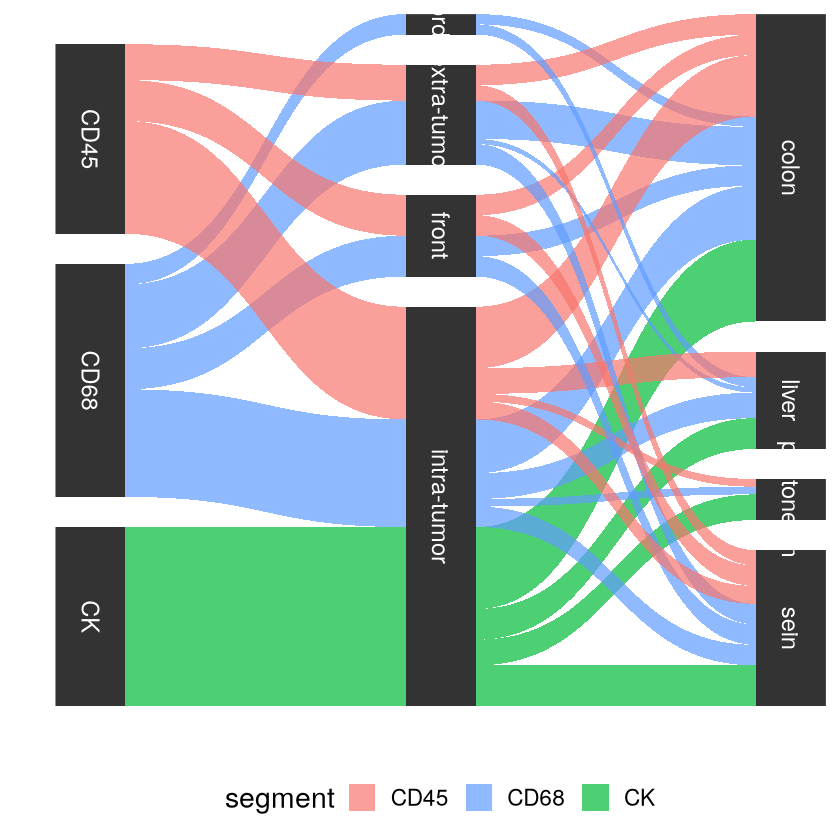

In [5]:
sankey_plot <- function(df,columns){
data <- table(df[,columns])
data <- reshape2::melt(data)
data <- gather_set_data(data, 1:3)
# Create the parallel sets diagram
ggplot(data, aes(x, id = id, split = y,value=value)) +
 geom_parallel_sets(aes(fill = segment), alpha = .7, axis.width = 0.2,sep = 0.05) +
 geom_parallel_sets_axes(axis.width = 0.2,sep = 0.05) +
 scale_fill_manual(values = c("CK" = ck_color, "CD45" = cd45_color,'CD68'=cd68_color)) +
    geom_parallel_sets_labels(color = "white", size = 5) +
    theme_classic(base_size = 17) + 
    theme(legend.position = "bottom",
          axis.ticks.y = element_blank(),
          axis.line = element_blank(),
          axis.text.y = element_blank()) +
    scale_y_continuous(expand = expansion(0)) + 
    scale_x_discrete(expand = expansion(0)) +
    labs(x = "", y = "") 
    }
sankey_plot(pData(demoData),c('segment','location','tissue'))

# QC & Pre-processing

## Select Segment QC

In [6]:
###### Default QC cutoffs are commented in () adjacent to the respective parameters
# study-specific values were selected after visualizing the QC results in more
# detail below
QC_params <-
        list(minSegmentReads = 1000, # Minimum number of reads (1000)
             percentTrimmed = 80,    # Minimum % of reads trimmed (80%)
             percentStitched = 80,   # Minimum % of reads stitched (80%)
             percentAligned = 75,    # Minimum % of reads aligned (80%)
             percentSaturation = 50, # Minimum sequencing saturation (50%)
             minNegativeCount = 1,   # Minimum negative control counts (10)
             maxNTCCount = 9000,     # Maximum counts observed in NTC well (1000)
             minNuclei = 20,         # Minimum # of nuclei estimated (100)
             minArea = 1000)         # Minimum segment area (5000)
demoData <-
        setSegmentQCFlags(demoData, 
                          qcCutoffs = QC_params)        

# Collate QC Results
QCResults <- protocolData(demoData)[["QCFlags"]]
flag_columns <- colnames(QCResults)
QC_Summary <- data.frame(Pass = colSums(!QCResults[, flag_columns]),
                         Warning = colSums(QCResults[, flag_columns]))
QCResults$QCStatus <- apply(QCResults, 1L, function(x) {
                                    ifelse(sum(x) == 0L, "PASS", "WARNING")
                         })
QC_Summary["TOTAL FLAGS", ] <-
        c(sum(QCResults[, "QCStatus"] == "PASS"),
          sum(QCResults[, "QCStatus"] == "WARNING"))

## Visualize Segment QC

Warning message:
“`aes_string()` was deprecated in ggplot2 3.0.0.
ℹ Please use tidy evaluation idioms with `aes()`.
ℹ See also `vignette("ggplot2-in-packages")` for more information.”


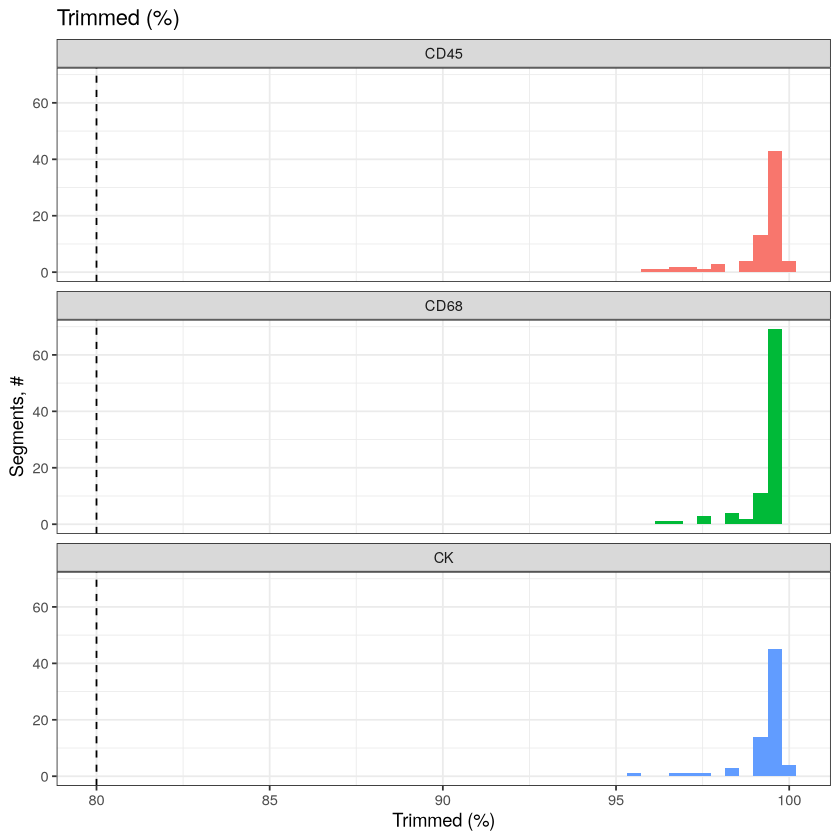

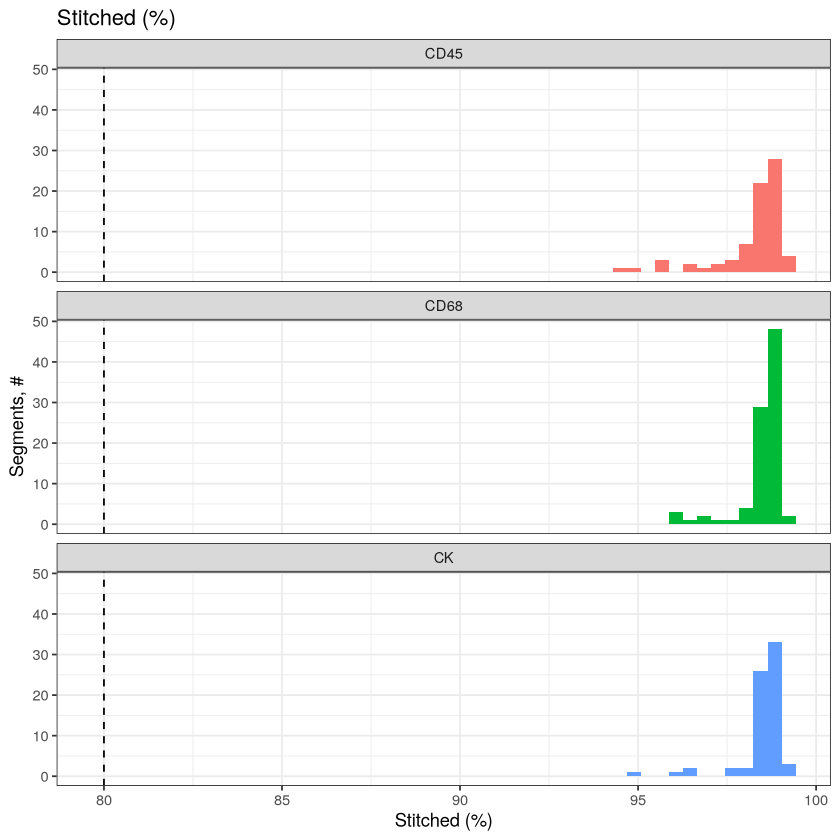

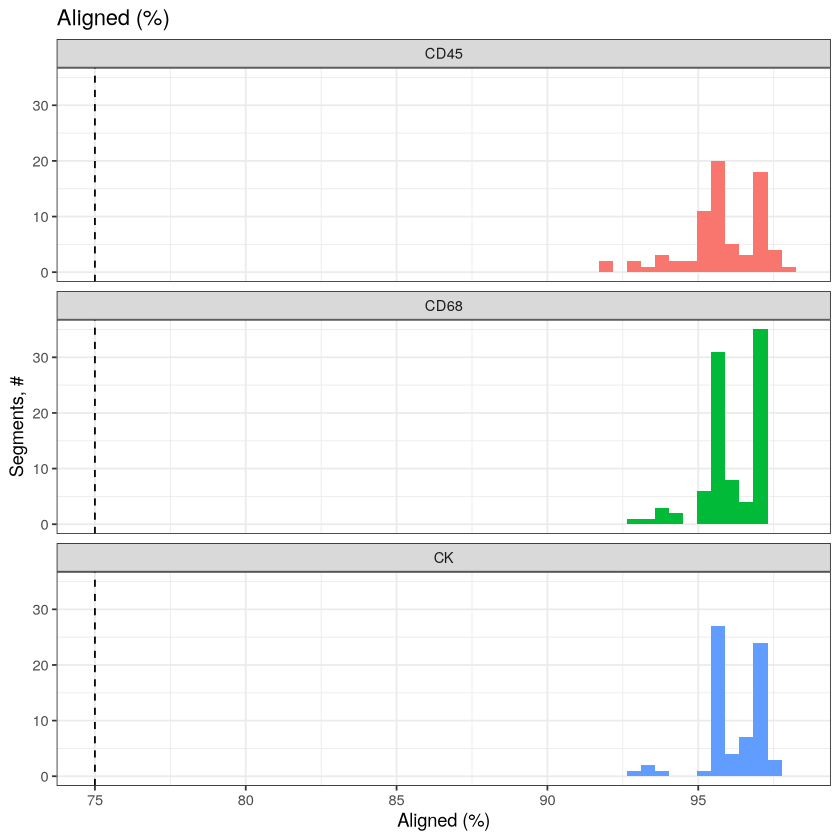

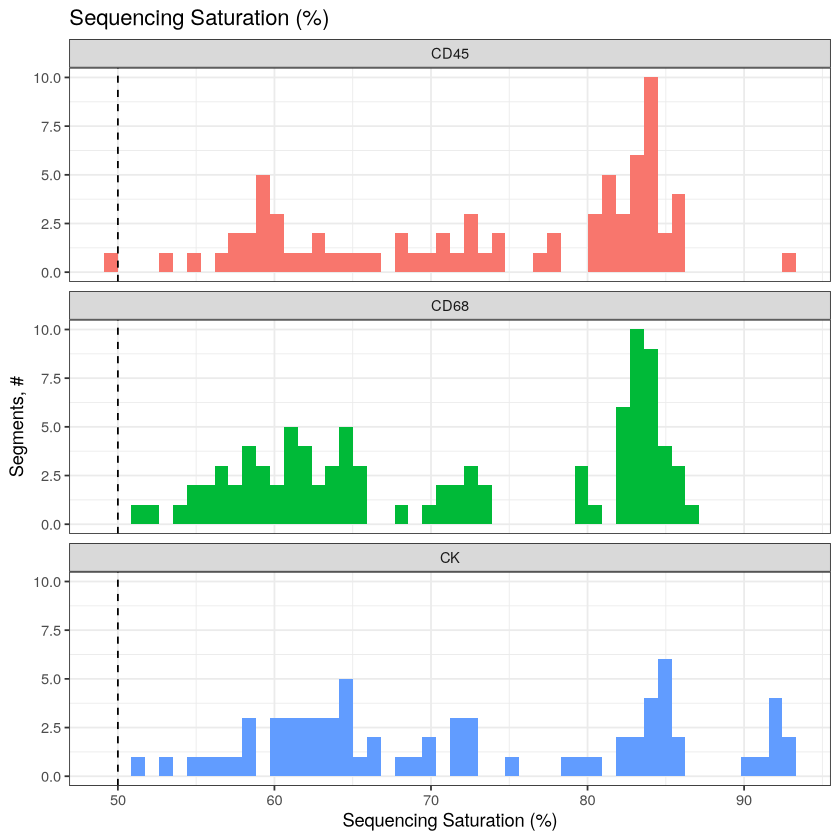

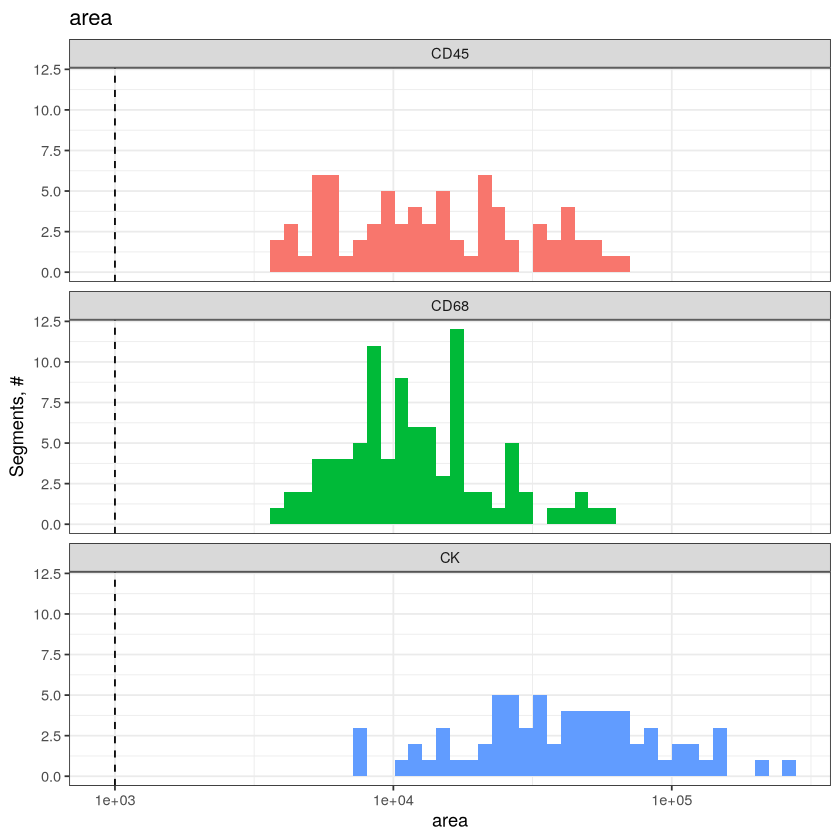



|NTC Count | # of Segments|
|:---------|-------------:|
|6         |            48|
|28        |            48|
|59        |             8|
|94        |            30|
|221       |             6|
|371       |            95|



Table: QC Summary Table for each Segment

|              | Pass| Warning|
|:-------------|----:|-------:|
|LowReads      |  235|       0|
|LowTrimmed    |  235|       0|
|LowStitched   |  235|       0|
|LowAligned    |  235|       0|
|LowSaturation |  234|       1|
|LowNegatives  |  235|       0|
|HighNTC       |  235|       0|
|LowArea       |  235|       0|
|TOTAL FLAGS   |  234|       1|

Features  Samples 
   18815      234

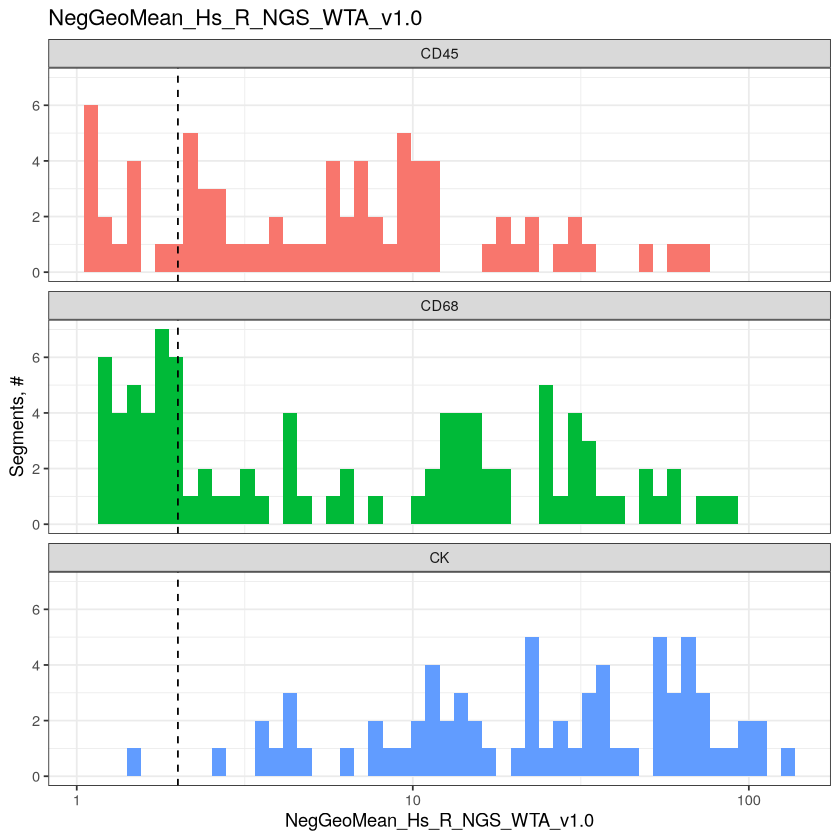

In [7]:
col_by <- "segment"

# Graphical summaries of QC statistics plot function
QC_histogram <- function(assay_data = NULL,
                         annotation = NULL,
                         fill_by = NULL,
                         thr = NULL,
                         scale_trans = NULL) {
        plt <- ggplot(assay_data,
                      aes_string(x = paste0("unlist(`", annotation, "`)"),
                                 fill = fill_by)) +
        geom_histogram(bins = 50) +
        geom_vline(xintercept = thr, lty = "dashed", color = "black") +
        theme_bw() + guides(fill = "none") +
        facet_wrap(as.formula(paste("~", fill_by)), nrow = 4) +
        labs(x = annotation, y = "Segments, #", title = annotation)
        if(!is.null(scale_trans)) { 
                plt <- plt + scale_x_continuous(trans = scale_trans) 
                }
                plt
        }

QC_histogram(sData(demoData), "Trimmed (%)", col_by, 80)
QC_histogram(sData(demoData), "Stitched (%)", col_by, 80)
QC_histogram(sData(demoData), "Aligned (%)", col_by, 75)
QC_histogram(sData(demoData), "Saturated (%)", col_by, 50) +
            labs(title = "Sequencing Saturation (%)",
                          x = "Sequencing Saturation (%)")
QC_histogram(sData(demoData), "area", col_by, 1000, scale_trans = "log10")
#QC_histogram(sData(demoData), "nuclei", col_by, 20)
# calculate the negative geometric means for each module
negativeGeoMeans <- 
            esBy(negativeControlSubset(demoData), 
                 GROUP = "Module", 
                 FUN = function(x) { 
                         assayDataApply(x, MARGIN = 2, FUN = ngeoMean, elt = "exprs") 
                 }) 

protocolData(demoData)[["NegGeoMean"]] <- negativeGeoMeans

# explicitly copy the Negative geoMeans from sData to pData
negCols <- paste0("NegGeoMean_", modules)
pData(demoData)[, negCols] <- sData(demoData)[["NegGeoMean"]]
for(ann in negCols) {
            plt <- QC_histogram(pData(demoData), ann, col_by, 2, scale_trans = "log10")
    print(plt)
}

# detatch neg_geomean columns ahead of aggregateCounts call
pData(demoData) <- pData(demoData)[, !colnames(pData(demoData)) %in% negCols]

# show all NTC values, Freq = # of Segments with a given NTC count:
kable(table(NTC_Count = sData(demoData)$NTC),
            col.names = c("NTC Count", "# of Segments"))

kable(QC_Summary, caption = "QC Summary Table for each Segment")
demoData <- demoData[, QCResults$QCStatus == "PASS"]
# Subsetting our dataset has removed samples which did not pass QC

dim(demoData)

# Probe QC

## Set Probe QC Flags

In [8]:
# Generally keep the qcCutoffs parameters unchanged. Set removeLocalOutliers to 
# FALSE if you do not want to remove local outliers
demoData <- setBioProbeQCFlags(demoData, 
                               qcCutoffs = list(minProbeRatio = 0.1,
                                                percentFailGrubbs = 20), 
                               removeLocalOutliers = TRUE)

ProbeQCResults <- fData(demoData)[["QCFlags"]]

# Define QC table for Probe QC
qc_df <- data.frame(Passed = sum(rowSums(ProbeQCResults[, -1]) == 0),
                    Global = sum(ProbeQCResults$GlobalGrubbsOutlier),
                    Local = sum(rowSums(ProbeQCResults[, -2:-1]) > 0
                                & !ProbeQCResults$GlobalGrubbsOutlier))
kable(qc_df)



| Passed| Global| Local|
|------:|------:|-----:|
|  18785|      0|    30|

## Exclude Outlier Probes

In [9]:
#Subset object to exclude all that did not pass Ratio & Global testing
ProbeQCPassed <- 
        subset(demoData, 
               fData(demoData)[["QCFlags"]][,c("LowProbeRatio")] == FALSE &
                       fData(demoData)[["QCFlags"]][,c("GlobalGrubbsOutlier")] == FALSE)
print("Probe QC Passed")
print(dim(ProbeQCPassed))
demoData <- ProbeQCPassed

[1] "Probe QC Passed"
Features  Samples 
   18815      234 


# Create Gene-level Count Data

In [10]:
# Check how many unique targets the object has
length(unique(featureData(demoData)[["TargetName"]]))

# collapse to targets
print(" collapse to targets ")
target_demoData <- aggregateCounts(demoData)

dim(target_demoData)
print("dim(target_demoData) before filtering")
print(dim(target_demoData))

print("Create Gene-level Count Data ")
exprs(target_demoData)[1:5, 1:2]
dim(pData(target_demoData))
pData(target_demoData)[1:3,]

# Limit of Quantification

# Define LOQ SD threshold and minimum value
cutoff <- 2
minLOQ <- 2

# Calculate LOQ per module tested
LOQ <- data.frame(row.names = colnames(target_demoData))
for(module in modules) {
    vars <- paste0(c("NegGeoMean_", "NegGeoSD_"),
                   module)
    if(all(vars[1:2] %in% colnames(pData(target_demoData)))) {
        LOQ[, module] <-
            pmax(minLOQ,
                 pData(target_demoData)[, vars[1]] * 
                     pData(target_demoData)[, vars[2]] ^ cutoff)
    }
}
# Create a new column initialized with NA

pData(target_demoData) <- cbind(pData(target_demoData), LOQ)
# pData(target_demoData)

[1] 18677

[1] " collapse to targets "


Features  Samples 
   18677      234

[1] "dim(target_demoData) before filtering"
Features  Samples 
   18677      234 
[1] "Create Gene-level Count Data "


,DSP-1001660005664-D-B04.dcc,DSP-1001660005664-D-B05.dcc
A2M,93,28
NAT2,74,18
ACADM,98,27
ACADS,112,15
ACAT1,106,27


[1] 234  10

,slide name,roi,segment,area,mucinous,tissue,patient_id,location,NegGeoMean_Hs_R_NGS_WTA_v1.0,NegGeoSD_Hs_R_NGS_WTA_v1.0
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>
DSP-1001660005664-D-B04.dcc,20H10907.05 PRIMITIVE 07-07-2022,001,CK,49378.06,false,colon,patient 2,intra-tumor,63.59545,1.319160
DSP-1001660005664-D-B05.dcc,20H10907.05 PRIMITIVE 07-07-2022,001,CD45,8680.18,false,colon,patient 2,intra-tumor,11.99941,1.596994
DSP-1001660005664-D-B06.dcc,20H10907.05 PRIMITIVE 07-07-2022,002,CK,21273.04,false,colon,patient 2,intra-tumor,27.86041,1.369415


# Filtering

In [11]:
LOQ_Mat <- c()
for(module in modules) {
        ind <- fData(target_demoData)$Module == module
        Mat_i <- t(esApply(target_demoData[ind, ], MARGIN = 1,
                           FUN = function(x) {
                                   x > LOQ[, module]
                           }))
        LOQ_Mat <- rbind(LOQ_Mat, Mat_i)
}
# ensure ordering since this is stored outside of the geomxSet
LOQ_Mat <- LOQ_Mat[fData(target_demoData)$TargetName, ]

## Segment Gene Detection



|       | CD45| CD68| CK|
|:------|----:|----:|--:|
|<1%    |    0|    0|  0|
|1-5%   |    5|    5|  0|
|5-10%  |   18|   30|  0|
|10-15% |    3|    9| 12|
|>15%   |   47|   47| 58|

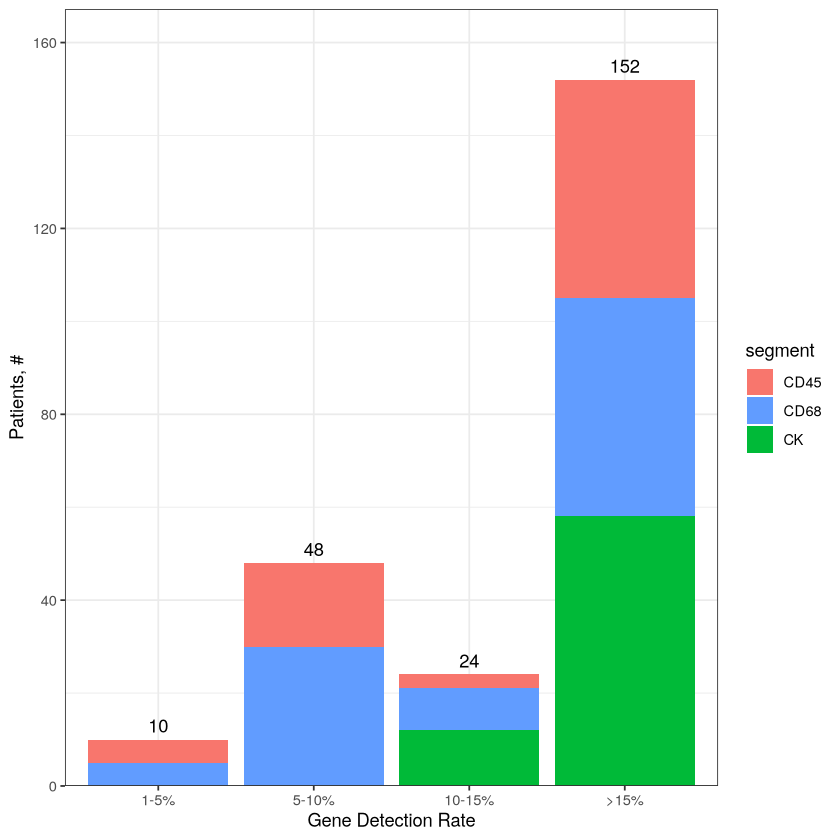

In [12]:
# Save detection rate information to pheno data
pData(target_demoData)$GenesDetected <- 
        colSums(LOQ_Mat, na.rm = TRUE)
pData(target_demoData)$GeneDetectionRate <-
        pData(target_demoData)$GenesDetected / nrow(target_demoData)

# Determine detection thresholds: 1%, 5%, 10%, 15%, >15%
pData(target_demoData)$DetectionThreshold <- 
        cut(pData(target_demoData)$GeneDetectionRate,
            breaks = c(0, 0.01, 0.05, 0.1, 0.15, 1),
            labels = c("<1%", "1-5%", "5-10%", "10-15%", ">15%"))

# stacked bar plot of different cut points (1%, 5%, 10%, 15%)
ggplot(pData(target_demoData),
       aes(x = DetectionThreshold)) +
geom_bar(aes(fill = segment)) +
geom_text(stat = "count", aes(label = after_stat(count)), vjust = -0.5) +
scale_fill_manual(values = c("CK" = ck_color, "CD45" = cd45_color,'CD68'=cd68_color)) +
theme_bw() +
scale_y_continuous(expand = expansion(mult = c(0, 0.1))) +
labs(x = "Gene Detection Rate",
     y = "Patients, #",
     fill = "segment")

# cut percent genes detected at 1, 5, 10, 15
kable(table(pData(target_demoData)$DetectionThreshold,pData(target_demoData)$segment))
#print("filter out segments with exceptionally low signal")

In [13]:
#library(xtable)
#xtable(t(table(pData(target_demoData)$DetectionThreshold, pData(target_demoData)$patient_id)))
print("dim(target_demoData) after filtering")
print(dim(target_demoData))
target_demoData <- target_demoData[, pData(target_demoData)$GeneDetectionRate >= .01]
print("dim(target_demoData) after filtering")
print(dim(target_demoData))
dim(target_demoData)

[1] "dim(target_demoData) after filtering"
Features  Samples 
   18677      234 
[1] "dim(target_demoData) after filtering"
Features  Samples 
   18677      234 


Features  Samples 
   18677      234

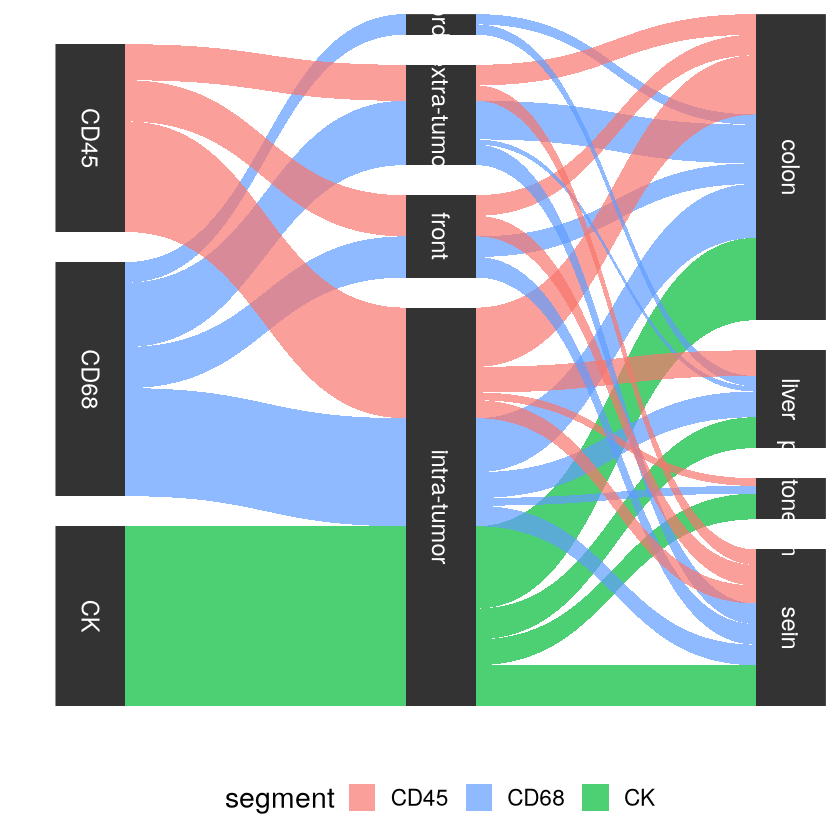

In [14]:
sankey_plot(pData(target_demoData),c('segment','location','tissue'))

## Gene Detection Rate

[1] "dim(target_demoData)"
Features  Samples 
   17512      234 


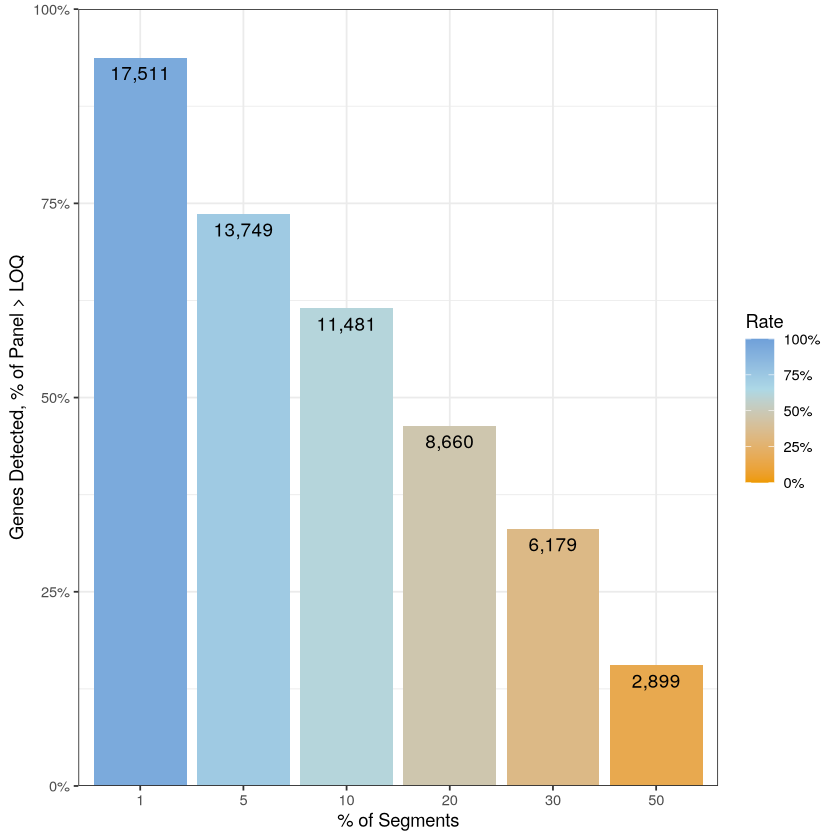

In [15]:
# Calculate detection rate:
LOQ_Mat <- LOQ_Mat[, colnames(target_demoData)]
fData(target_demoData)$DetectedSegments <- rowSums(LOQ_Mat, na.rm = TRUE)
fData(target_demoData)$DetectionRate <-
        fData(target_demoData)$DetectedSegments / nrow(pData(target_demoData))

# Plot detection rate:
plot_detect <- data.frame(Freq = c(1, 5, 10, 20, 30, 50))
plot_detect$Number <-
        unlist(lapply(c(0.01, 0.05, 0.1, 0.2, 0.3, 0.5),
                      function(x) {sum(fData(target_demoData)$DetectionRate >= x)}))
plot_detect$Rate <- plot_detect$Number / nrow(fData(target_demoData))
rownames(plot_detect) <- plot_detect$Freq

ggplot(plot_detect, aes(x = as.factor(Freq), y = Rate, fill = Rate)) +
        geom_bar(stat = "identity") +
        geom_text(aes(label = formatC(Number, format = "d", big.mark = ",")),
                  vjust = 1.6, color = "black", size = 4) +
scale_fill_gradient2(low = "orange2", mid = "lightblue",
                     high = "dodgerblue3", midpoint = 0.65,
                     limits = c(0,1),
                     labels = scales::percent) +
theme_bw() +
scale_y_continuous(labels = scales::percent, limits = c(0,1),
                   expand = expansion(mult = c(0, 0))) +
labs(x = "% of Segments",y = "Genes Detected, % of Panel > LOQ")


# Subset to target genes detected in at least 10% of the samples.
#   Also manually include the negative control probe, for downstream use
negativeProbefData <- subset(fData(target_demoData), CodeClass == "Negative")
neg_probes <- unique(negativeProbefData$TargetName)

######## !!!!!!!!!!!!!!! ################
target_demoData <- 
        target_demoData[fData(target_demoData)$DetectionRate >= 0.01 |
                        fData(target_demoData)$TargetName %in% neg_probes, ]
print("dim(target_demoData)")
print(dim(target_demoData))

# Normalization

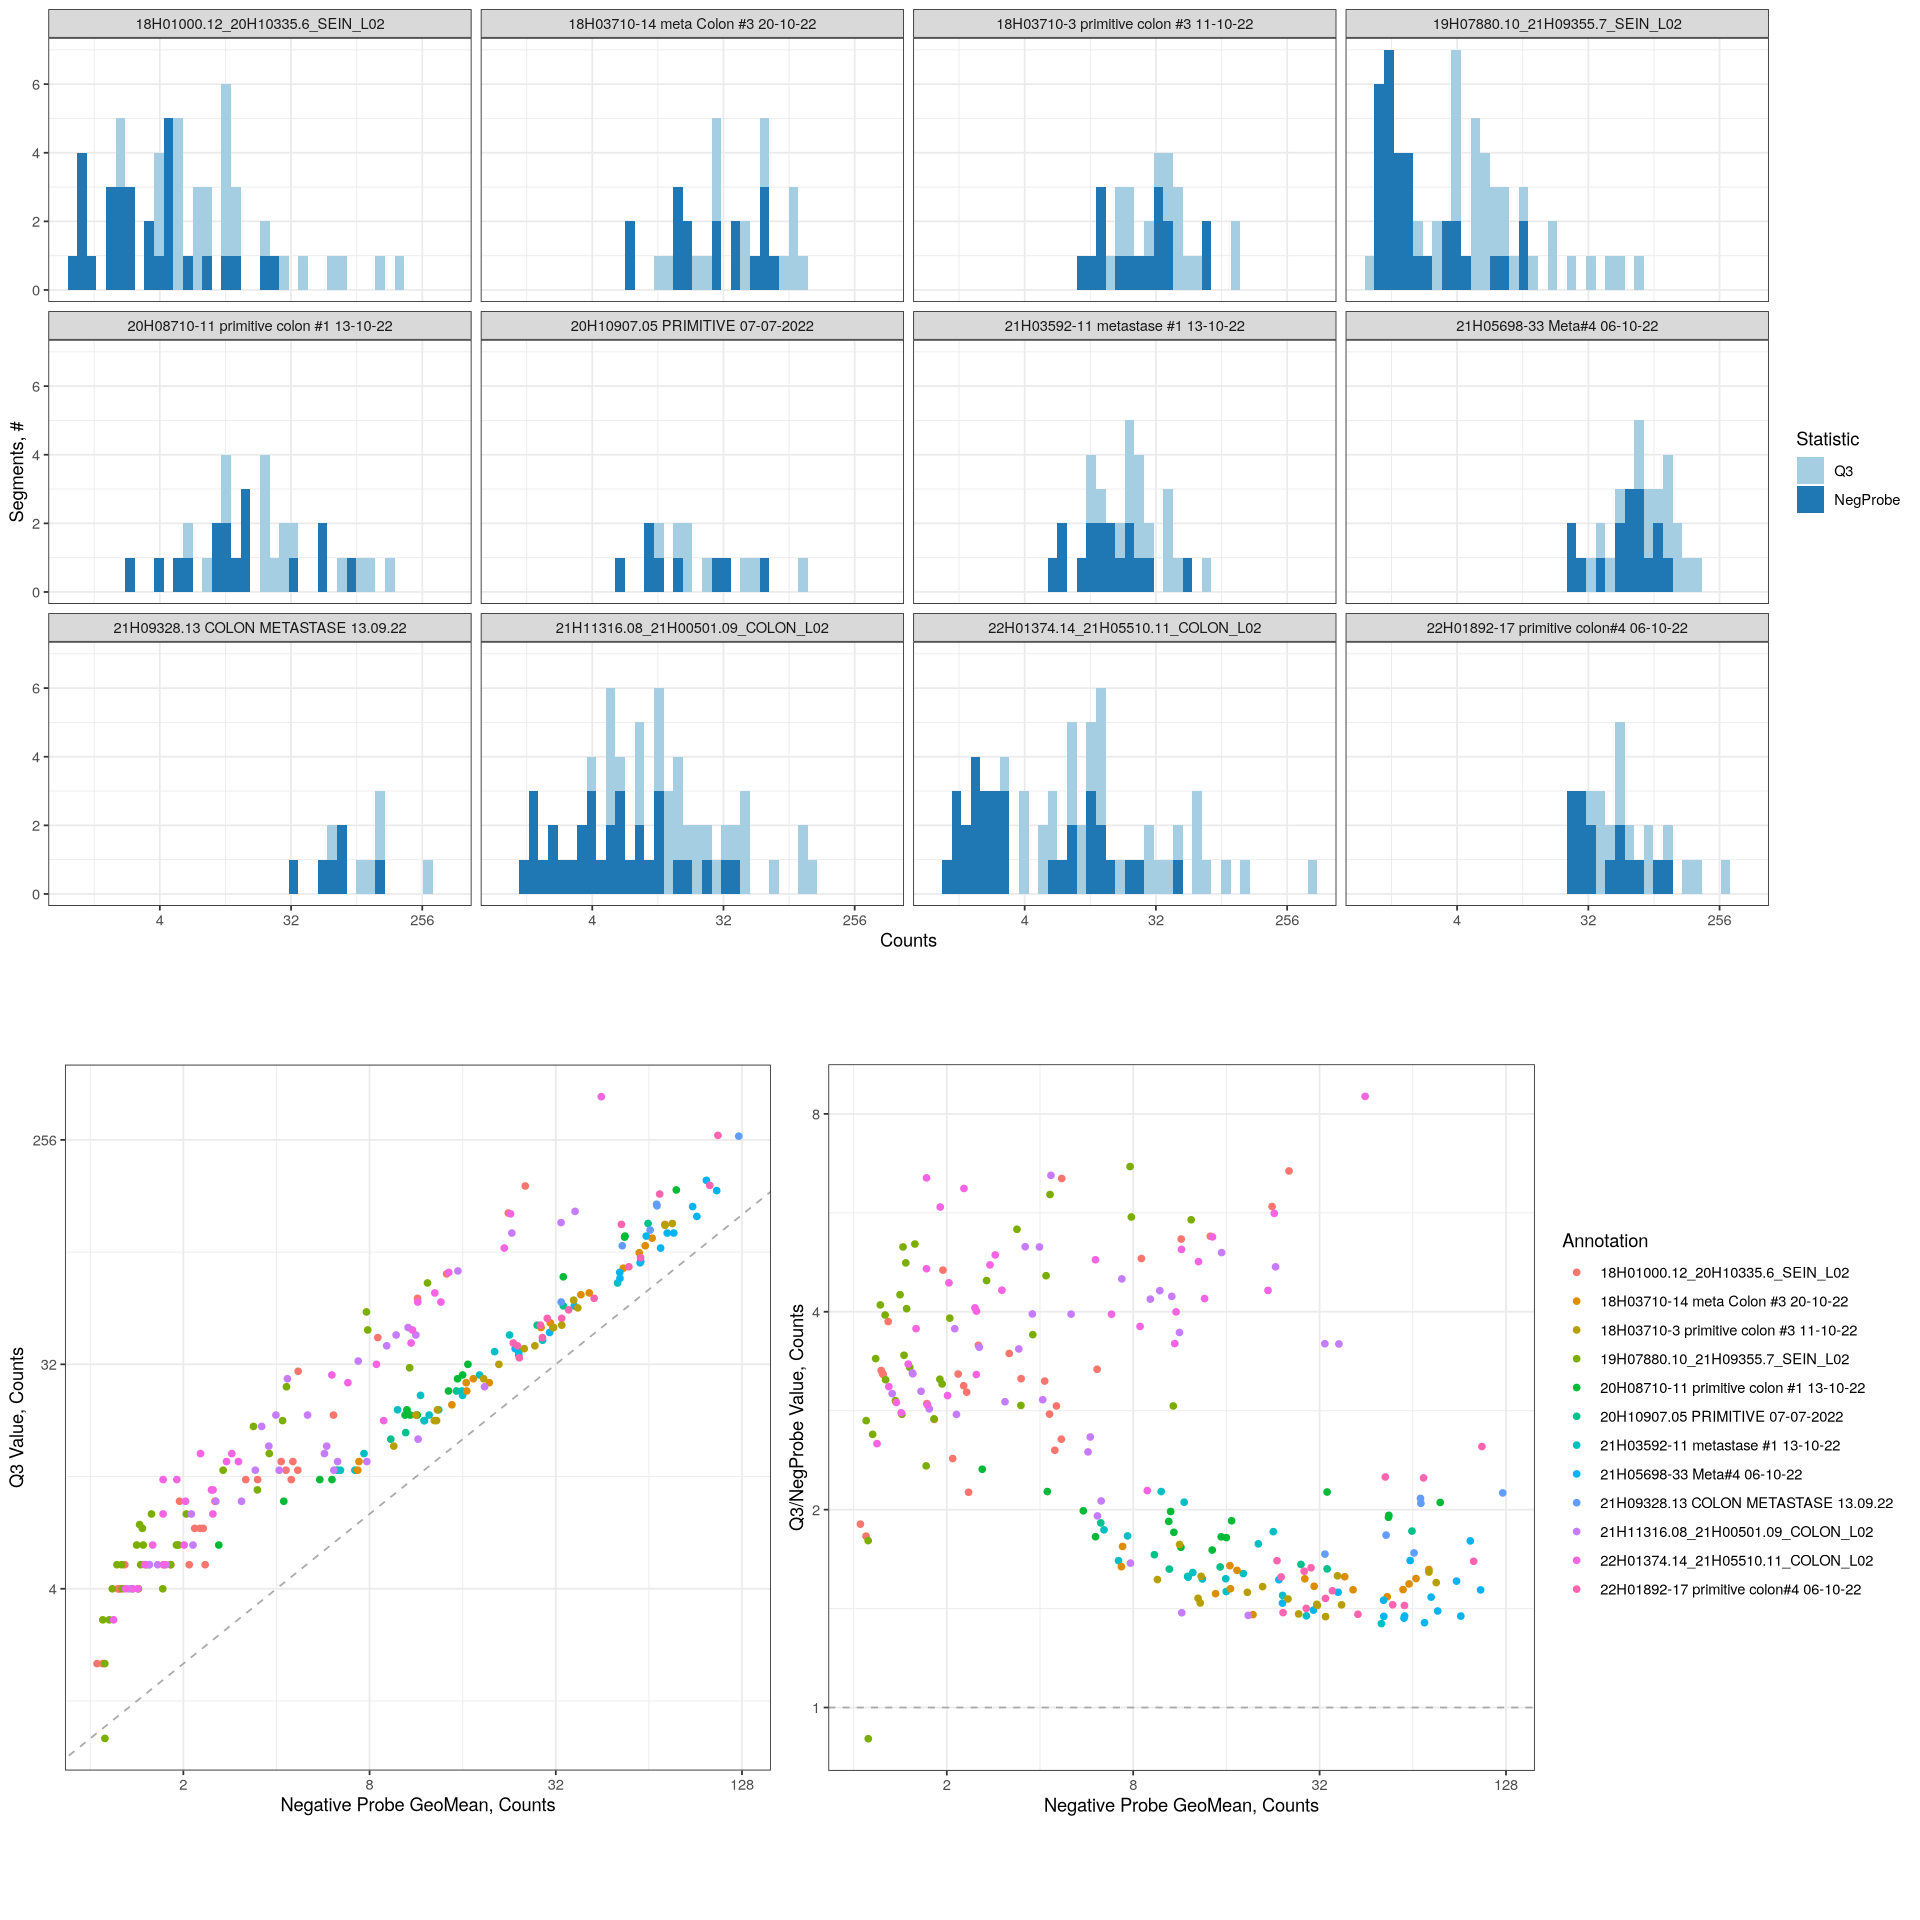

In [16]:
library(reshape2)  # for melt
library(cowplot)   # for plot_grid

# Graph Q3 value vs negGeoMean of Negatives
ann_of_interest <- "slide name"
Stat_data <- 
        data.frame(row.names = colnames(exprs(target_demoData)),
                   Segment = colnames(exprs(target_demoData)),
                   Annotation = pData(target_demoData)[, ann_of_interest],
                   Q3 = unlist(apply(exprs(target_demoData), 2,
                                     quantile, 0.75, na.rm = TRUE)),
                   NegProbe = exprs(target_demoData)[neg_probes, ])
Stat_data_m <- melt(Stat_data, measure.vars = c("Q3", "NegProbe"),
                    variable.name = "Statistic", value.name = "Value")

plt1 <- ggplot(Stat_data_m,
               aes(x = Value, fill = Statistic)) +
geom_histogram(bins = 40) + theme_bw() +
scale_x_continuous(trans = "log2") +
facet_wrap(~Annotation, nrow = 3) + 
scale_fill_brewer(palette = 3, type = "qual") +
labs(x = "Counts", y = "Segments, #")
#plt1
            plt2 <- ggplot(Stat_data,
                           aes(x = NegProbe, y = Q3, color = Annotation)) +
geom_abline(intercept = 0, slope = 1, lty = "dashed", color = "darkgray") +
geom_point() + guides(color = "none") + theme_bw() +
scale_x_continuous(trans = "log2") + 
scale_y_continuous(trans = "log2") +
theme(aspect.ratio = 1) +
labs(x = "Negative Probe GeoMean, Counts", y = "Q3 Value, Counts")
#plt2
                plt3 <- ggplot(Stat_data,
                               aes(x = NegProbe, y = Q3 / NegProbe, color = Annotation)) +
geom_hline(yintercept = 1, lty = "dashed", color = "darkgray") +
geom_point() + theme_bw() +
scale_x_continuous(trans = "log2") + 
scale_y_continuous(trans = "log2") +
theme(aspect.ratio = 1) +
labs(x = "Negative Probe GeoMean, Counts", y = "Q3/NegProbe Value, Counts")
#plt3
options(repr.plot.width=16, repr.plot.height=16)

                btm_row <- plot_grid(plt2, plt3, nrow = 1, labels = c("", ""),
                                     rel_widths = c(0.39,0.57))
plot_grid(plt1, btm_row, ncol = 1, labels = c("", ""))
options(repr.plot.width=NULL, repr.plot.height=NULL)

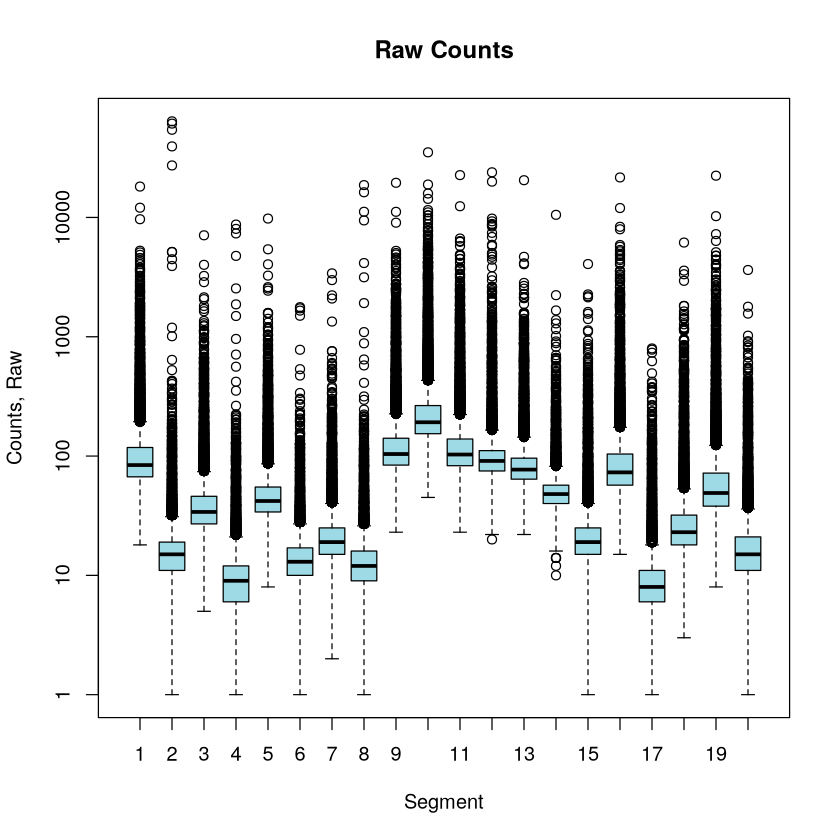

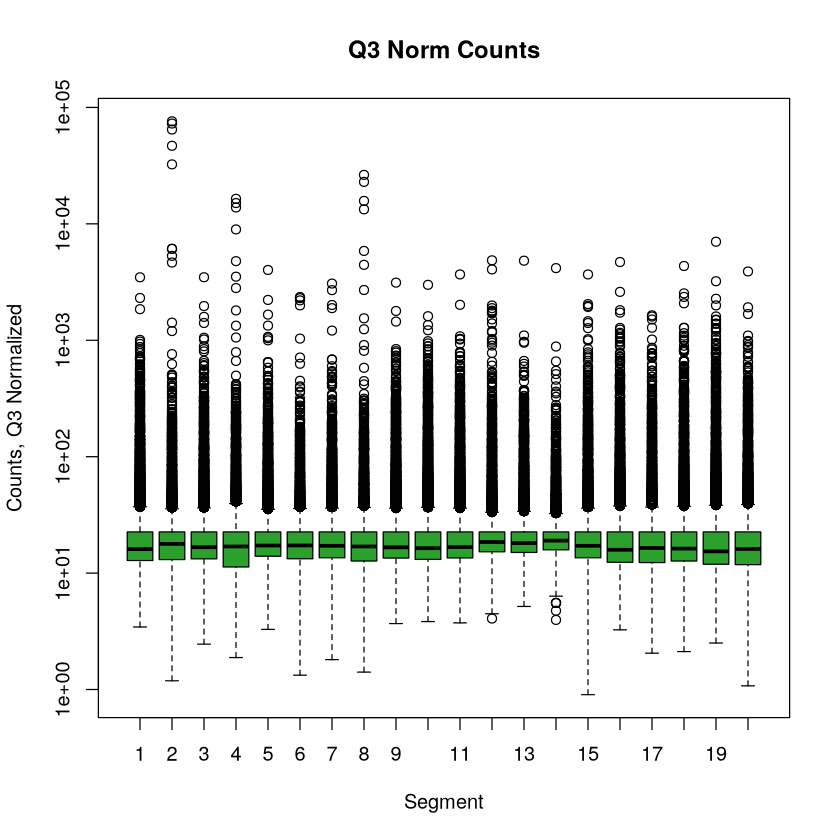

 [1] "slide name"                   "roi"                         
 [3] "segment"                      "area"                        
 [5] "mucinous"                     "tissue"                      
 [7] "patient_id"                   "location"                    
 [9] "NegGeoMean_Hs_R_NGS_WTA_v1.0" "NegGeoSD_Hs_R_NGS_WTA_v1.0"  
[11] "Hs_R_NGS_WTA_v1.0"            "GenesDetected"               
[13] "GeneDetectionRate"            "DetectionThreshold"          
[15] "q_norm_qFactors"              "neg_norm_negFactors"         
[1] 234


Features  Samples 
   17512      234

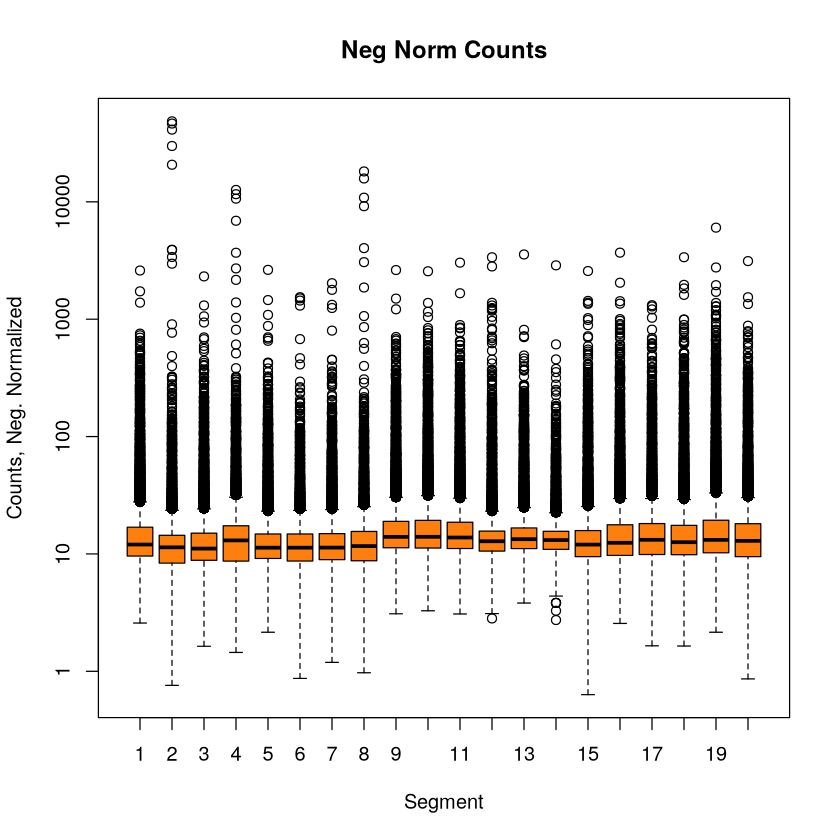

In [17]:
# Q3 norm (75th percentile) for WTA/CTA  with or without custom spike-ins
target_demoData <- normalize(target_demoData ,
                             norm_method = "quant", 
                             desiredQuantile = .75,
                             toElt = "q_norm")

# Background normalization for WTA/CTA without custom spike-in
target_demoData <- normalize(target_demoData ,
                             norm_method = "neg", 
                             fromElt = "exprs",
                             toElt = "neg_norm")

len <- dim(target_demoData)[2][]
str <- paste(len,collape="")


# visualize the first 10 segments with each normalization method
boxplot(exprs(target_demoData)[,1:20],
        col = "#9EDAE5", main = "Raw Counts",
        log = "y", names = 1:20, xlab = "Segment",
        ylab = "Counts, Raw")

boxplot(assayDataElement(target_demoData[,1:20], elt = "q_norm"),
        col = "#2CA02C", main = "Q3 Norm Counts",
        log = "y", names = 1:20, xlab = "Segment",
        ylab = "Counts, Q3 Normalized")

boxplot(assayDataElement(target_demoData[,1:20], elt = "neg_norm"),
        col = "#FF7F0E", main = "Neg Norm Counts",
        log = "y", names = 1:20, xlab = "Segment",
        ylab = "Counts, Neg. Normalized")
print(colnames(pData(target_demoData)))
print(nrow(pData(target_demoData)))
dim(target_demoData)

# Save Object

In [18]:
save(target_demoData,file = '/home/dimitris/Workspace/crc/data/geomx_crc.RData')

In [27]:
write.csv(pData(target_demoData),"/home/dimitris/Workspace/crc/data/geomx_metadata.csv")

In [28]:
pData(target_demoData)

,slide name,roi,segment,area,mucinous,tissue,patient_id,location,NegGeoMean_Hs_R_NGS_WTA_v1.0,NegGeoSD_Hs_R_NGS_WTA_v1.0,Hs_R_NGS_WTA_v1.0,GenesDetected,GeneDetectionRate,DetectionThreshold,q_norm_qFactors,neg_norm_negFactors
,<chr>,<chr>,<chr>,<dbl>,<chr>,<chr>,<chr>,<chr>,<dbl>,<dbl>,<dbl>,<dbl>,<dbl>,<fct>,<dbl>,"<dbl[,1]>"
DSP-1001660005664-D-B04.dcc,20H10907.05 PRIMITIVE 07-07-2022,001,CK,49378.06,false,colon,patient 2,intra-tumor,63.595447,1.319160,110.667742,5009,0.26819082,>15%,5.2266961,6.9835466
DSP-1001660005664-D-B05.dcc,20H10907.05 PRIMITIVE 07-07-2022,001,CD45,8680.18,false,colon,patient 2,intra-tumor,11.999409,1.596994,30.603188,977,0.05231033,5-10%,0.8415867,1.3176797
DSP-1001660005664-D-B06.dcc,20H10907.05 PRIMITIVE 07-07-2022,002,CK,21273.04,false,colon,patient 2,intra-tumor,27.860407,1.369415,52.246546,3044,0.16298121,>15%,2.0375256,3.0594085
DSP-1001660005664-D-B07.dcc,20H10907.05 PRIMITIVE 07-07-2022,002,CD45,5123.74,false,colon,patient 2,intra-tumor,6.285589,1.798526,20.331966,957,0.05123949,5-10%,0.5315284,0.6902334
DSP-1001660005664-D-B08.dcc,20H10907.05 PRIMITIVE 07-07-2022,003,CK,22481.72,false,colon,patient 2,intra-tumor,33.842308,1.363252,62.894466,3016,0.16148204,>15%,2.4361719,3.7162934
DSP-1001660005664-D-B09.dcc,20H10907.05 PRIMITIVE 07-07-2022,003,CD45,5281.40,false,colon,patient 2,intra-tumor,10.467338,1.580810,26.157474,781,0.04181614,1-5%,0.7529986,1.1494399
DSP-1001660005664-D-B10.dcc,20H10907.05 PRIMITIVE 07-07-2022,004,CK,10927.30,false,colon,patient 2,intra-tumor,15.278281,1.457249,32.444555,1965,0.10520962,10-15%,1.1073509,1.6777394
DSP-1001660005664-D-B11.dcc,20H10907.05 PRIMITIVE 07-07-2022,004,CD45,5956.76,false,colon,patient 2,intra-tumor,9.366657,1.579086,23.355888,1046,0.05600471,5-10%,0.7087046,1.0285718
DSP-1001660005664-D-C10.dcc,21H09328.13 COLON METASTASE 13.09.22,001,CK,58566.87,false,liver,patient 2,intra-tumor,67.772620,1.313310,116.893134,6788,0.36344167,>15%,6.2454589,7.4422506


In [31]:
write.csv(assayDataElement(object = target_demoData, elt = "q_norm") ,"/home/dimitris/Workspace/crc/data/geomx_normalized_counts.csv")